# 03 — Modelado, Evaluación y Serialización

**Proyecto:** FinBalance — Predicción de Fragilidad Financiera  
**Tarea:** Clasificación multiclase (3 clases: Baja / Media / Alta)  
**Métrica principal:** F1-score macro (maneja desbalance de clases)  

---

### Contenido
1. Carga de datos procesados  
2. Baseline — modelo trivial  
3. Experimentación — comparación de algoritmos  
4. Evaluación del mejor modelo sobre test  
5. Importancia de features  
6. Serialización del modelo  
7. Guardado de metadatos

---
## 0 — Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import date

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    roc_auc_score, roc_curve
)

AZUL  = '#1F4E79'
TEAL  = '#1D9E75'
CORAL = '#D95A30'
AMBER = '#BA7517'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

RUTA_PROC   = Path('../data/processed')
RUTA_MODELS = Path('../models')
RUTA_MODELS.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
print('Imports completados.')

Imports completados.


---
## 1 — Carga de datos procesados

Los conjuntos train/validacion/test fueron generados en `02_eda_limpieza.ipynb` con split estratificado 70/15/15.

In [2]:
train = pd.read_csv(RUTA_PROC / 'train.csv')
test  = pd.read_csv(RUTA_PROC / 'test.csv')
val   = pd.read_csv(RUTA_PROC / 'validacion.csv')

TARGET = 'fragilidad_label'

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET].astype(int)

# test.csv: ajuste y seleccion de modelo (comparacion de algoritmos, GridSearchCV)
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET].astype(int)

# validacion.csv: evaluacion final, se usa UNA SOLA VEZ al final
X_val   = val.drop(columns=[TARGET])
y_val   = val[TARGET].astype(int)

print(f'Train      : {X_train.shape}  |  clases: {dict(y_train.value_counts().sort_index())}')
print(f'Test       : {X_test.shape}   |  clases: {dict(y_test.value_counts().sort_index())}')
print(f'Validacion : {X_val.shape}   |  clases: {dict(y_val.value_counts().sort_index())}')
print(f'\nFeatures: {X_train.shape[1]}')
print(f'Clases  : 1=Baja  2=Media  3=Alta')


Train      : (3658, 40)  |  clases: {1: np.int64(815), 2: np.int64(1439), 3: np.int64(1404)}
Test       : (785, 40)   |  clases: {1: np.int64(175), 2: np.int64(309), 3: np.int64(301)}
Validacion : (784, 40)   |  clases: {1: np.int64(175), 2: np.int64(308), 3: np.int64(301)}

Features: 40
Clases  : 1=Baja  2=Media  3=Alta


---
## 2 — Baseline: modelo trivial

Antes de entrenar cualquier modelo real, establecemos un **baseline** con `DummyClassifier`.  
Todo modelo real debe superar este piso — si no lo supera, hay un problema en el pipeline.

In [3]:
# Se incluye un baseline con DummyClassifier para validar que los modelos superen una estrategia trivial
dummy = DummyClassifier(strategy='most_frequent', random_state=SEMILLA)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print('=== BASELINE (DummyClassifier - clase mas frecuente) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_dummy):.3f}')
print(f'F1 macro : {f1_score(y_test, y_pred_dummy, average="macro"):.3f}')
print()
print('Cualquier modelo real debe superar F1 macro > {:.3f}'.format(
    f1_score(y_test, y_pred_dummy, average='macro')))


=== BASELINE (DummyClassifier - clase mas frecuente) ===
Accuracy : 0.394
F1 macro : 0.188

Cualquier modelo real debe superar F1 macro > 0.188


---
## 3 — Experimentación: comparación de algoritmos

Entrenamos **4 algoritmos** usando `Pipeline` con `StandardScaler` para evitar fuga de datos.  
El escalador se ajusta únicamente con datos de entrenamiento y se aplica a validación y test.

### ¿Por qué F1 macro como métrica principal?

El dataset tiene desbalance de clases (más encuestados en categorías de fragilidad media/baja).  
F1 macro promedia el F1 de cada clase con igual peso, penalizando modelos que ignoran clases minoritarias.  
Si usáramos accuracy, un modelo que predice siempre 'Media' podría tener accuracy alta pero ser inútil.

In [4]:
# Definición de los 4 modelos a comparar
modelos = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEMILLA),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=SEMILLA),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, random_state=SEMILLA),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=SEMILLA),
}

resultados = []
pipelines  = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()), # Escalamiento de datos
        ('clf',    modelo) # Modelo a evaluar
    ])
    pipe.fit(X_train, y_train) # Entrenamiento del modelo
    y_pred = pipe.predict(X_test) # Predicciones con los datos de validación

    acc  = accuracy_score(y_test, y_pred) # Porcentaje de predicciones correctas
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

    resultados.append({'Modelo': nombre, 'Accuracy': acc,
                       'F1 macro': f1, 'Precision macro': prec, 'Recall macro': rec})
    pipelines[nombre] = pipe
    print(f'{nombre:<22} | Acc: {acc:.3f} | F1: {f1:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f}')

df_res = pd.DataFrame(resultados).sort_values('F1 macro', ascending=False).reset_index(drop=True)
print()
print('Ranking por F1 macro (test):')
print(df_res.to_string(index=False))


Logistic Regression    | Acc: 0.520 | F1: 0.480 | Prec: 0.506 | Rec: 0.480
Decision Tree          | Acc: 0.518 | F1: 0.470 | Prec: 0.512 | Rec: 0.473
Random Forest          | Acc: 0.529 | F1: 0.484 | Prec: 0.541 | Rec: 0.485
Gradient Boosting      | Acc: 0.516 | F1: 0.483 | Prec: 0.511 | Rec: 0.480

Ranking por F1 macro (test):
             Modelo  Accuracy  F1 macro  Precision macro  Recall macro
      Random Forest  0.528662  0.484108         0.541150      0.484517
  Gradient Boosting  0.515924  0.482700         0.510908      0.480194
Logistic Regression  0.519745  0.480124         0.506384      0.480298
      Decision Tree  0.518471  0.469803         0.512298      0.473036


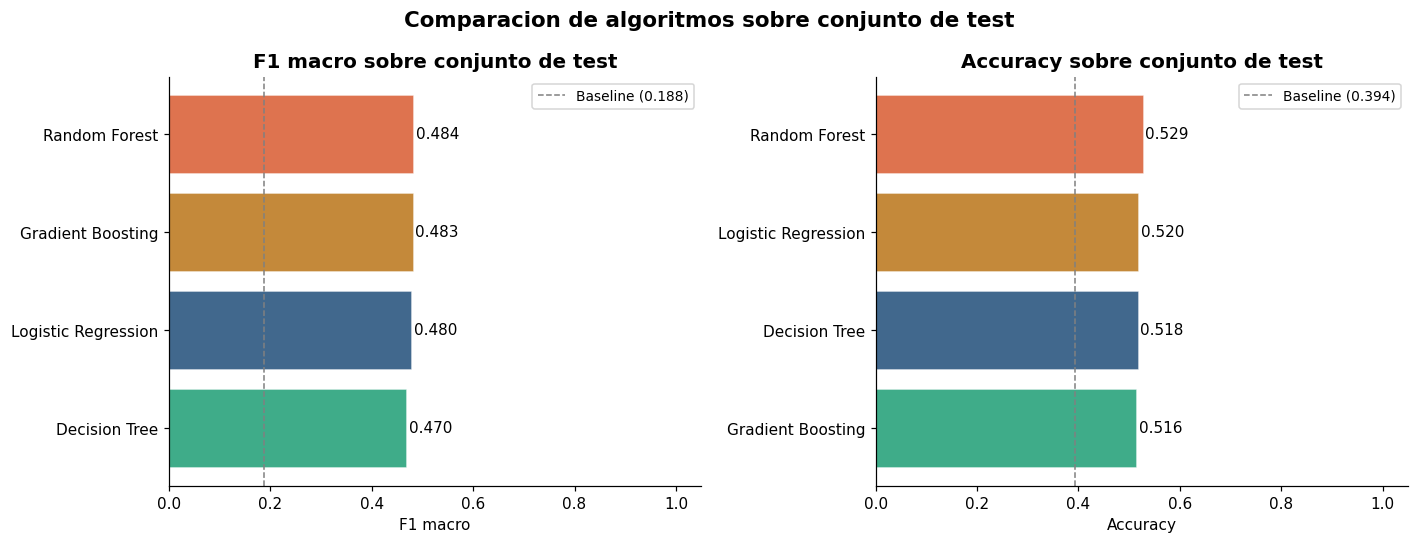

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metricas = ['F1 macro', 'Accuracy']
colores  = [TEAL, AZUL, AMBER, CORAL]

for ax, metrica in zip(axes, metricas):
    df_plot = df_res.sort_values(metrica)
    bars = ax.barh(df_plot['Modelo'], df_plot[metrica],
                   color=colores[:len(df_plot)], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, df_plot[metrica]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlabel(metrica)
    ax.set_title(f'{metrica} sobre conjunto de test')
    ax.set_xlim(0, 1.05)
    baseline_f1 = f1_score(y_test, y_pred_dummy, average='macro')
    ref = baseline_f1 if metrica == 'F1 macro' else accuracy_score(y_test, dummy.predict(X_test))
    ax.axvline(ref, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({ref:.3f})')
    ax.legend(fontsize=9)

plt.suptitle('Comparacion de algoritmos sobre conjunto de test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/viz_05_comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
# Validación cruzada del mejor modelo sobre train (5 folds estratificados)
mejor_nombre = df_res.iloc[0]['Modelo']
mejor_pipe   = pipelines[mejor_nombre]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
# La validación cruzada divide X_train en 5 partes iguales. En cada vuelta entrena con 4 partes y evalúa con la quinta. Al final tienes 5 puntajes distintos.
scores_cv = cross_val_score(mejor_pipe, X_train, y_train,
                             cv=cv, scoring='f1_macro')

print(f'Mejor modelo: {mejor_nombre}')
#  promedio de los 5 puntajes — qué tan bien clasifica en promedio  + desviación estándar — qué tan estables son esos puntajes entre sí
print(f'CV F1 macro (5 folds): {scores_cv.mean():.3f} +/- {scores_cv.std():.3f}')
# indicaría si el modelo falla con cierto subgrupo de datos
print(f'Random Forest:     {scores_cv}  ->  media={scores_cv.mean():.4f}  std={scores_cv.std():.4f}')

Mejor modelo: Random Forest
CV F1 macro (5 folds): 0.476 +/- 0.014
Random Forest:     [0.49686665 0.46801061 0.47965768 0.47972291 0.4553696 ]  ->  media=0.4759  std=0.0138


---
## 3.5 — Tuning del mejor modelo con GridSearchCV

Una vez identificado el mejor algoritmo en la sección anterior, se buscan los
hiperparámetros óptimos usando búsqueda exhaustiva sobre una grilla definida.

- La búsqueda usa **validación cruzada estratificada (5 folds)** sobre el conjunto de entrenamiento.
- La métrica de selección es `f1_macro`, consistente con el criterio del proyecto.
- El conjunto de **validación y test no se tocan** en este paso.

In [7]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV: busqueda exhaustiva de hiperparametros
# GridSearchCV prueba todas las combinaciones posibles de la grilla y elige la mejor
# segun la metrica definida en scoring, usando validacion cruzada para cada combinacion.

# La grilla define que valores probar para cada hiperparametro.
# El prefijo 'clf__' indica que el parametro pertenece al paso 'clf' del Pipeline.
# Total de combinaciones: 3 x 3 x 3 = 27 modelos entrenados x 5 folds = 135 entrenamientos
param_grid = {
    'clf__n_estimators'    : [100, 200, 300],    # cantidad de arboles en el bosque
    'clf__max_depth'       : [None, 10, 20],     # profundidad maxima de cada arbol (None = sin limite)
    'clf__min_samples_split': [2, 5, 10],        # minimo de muestras para dividir un nodo
}

# StratifiedKFold garantiza que cada fold conserve la proporcion de clases del dataset original
cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

gs = GridSearchCV(
    mejor_pipe,          # pipeline completo: StandardScaler + RandomForest
    param_grid,          # grilla de combinaciones a probar
    scoring='f1_macro',  # metrica para decidir cual combinacion es la mejor
    cv=cv_gs,            # validacion cruzada con 5 folds estratificados
    n_jobs=-1,           # usar todos los nucleos del CPU en paralelo
    verbose=1,           # mostrar progreso en pantalla
)
# fit entrena las 135 combinaciones y guarda internamente cual obtuvo mejor f1_macro
gs.fit(X_train, y_train)

# best_params_: la combinacion ganadora
# best_score_: el f1_macro promedio de esa combinacion en los 5 folds
print(f'Mejores hiperparametros : {gs.best_params_}')
print(f'F1 macro CV (best)      : {gs.best_score_:.4f}')
print(f'F1 macro CV (anterior)  : {scores_cv.mean():.4f}')
print(f'Ganancia del tuning     : {gs.best_score_ - scores_cv.mean():+.4f}')


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparametros : {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
F1 macro CV (best)      : 0.4808
F1 macro CV (anterior)  : 0.4759
Ganancia del tuning     : +0.0049


In [8]:
# Evaluar el modelo tuneado sobre validación y decidir si reemplaza al anterior
mejor_pipe_tuned = gs.best_estimator_
y_pred_tuned     = mejor_pipe_tuned.predict(X_test)
f1_tuned         = f1_score(y_test, y_pred_tuned, average='macro') #average='macro' — promedio simple, todas las clases pesan igual
f1_original      = df_res.iloc[0]['F1 macro']

print(f'F1 macro test - original : {f1_original:.4f}')
print(f'F1 macro test - tuneado  : {f1_tuned:.4f}')
print(f'Diferencia               : {f1_tuned - f1_original:+.4f}')
print()

if f1_tuned > f1_original:
    mejor_pipe = mejor_pipe_tuned
    print('Modelo actualizado: se usa el pipeline tuneado para la validacion final.')
else:
    print('Sin mejora significativa: se mantiene el modelo original para la validacion final.')


F1 macro test - original : 0.4841
F1 macro test - tuneado  : 0.4681
Diferencia               : -0.0160

Sin mejora significativa: se mantiene el modelo original para la validacion final.


---
## 3.6 — Diagnostico: overfitting / underfitting

La **curva de aprendizaje** muestra como evolucionan el score de entrenamiento
y el score de validacion cruzada a medida que se aumenta el tamano del conjunto de entrenamiento.

| Patron en la grafica | Diagnostico |
|---|---|
| Train alto, CV bajo, brecha grande | **Overfitting** — el modelo memoriza, no generaliza |
| Train bajo, CV bajo, ambos juntos | **Underfitting** — el modelo no tiene capacidad suficiente |
| Train y CV convergen a un valor similar | **Buen ajuste** — el modelo generaliza correctamente |

> Si hay overfitting: reducir complejidad (`max_depth`, `min_samples_split`) o agregar mas datos.
> Si hay underfitting: aumentar complejidad o revisar las features.

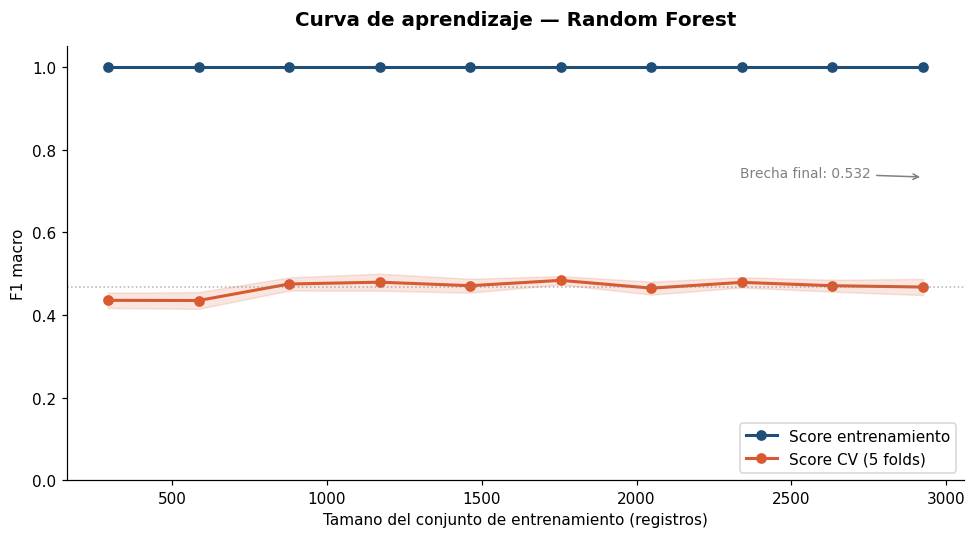

Score entrenamiento final : 1.000 +/- 0.000
Score CV final            : 0.468 +/- 0.020
Brecha (train - CV)       : 0.532

Diagnostico: OVERFITTING — brecha > 0.15. Considerar reducir complejidad.


In [9]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, cv_scores = learning_curve(
    mejor_pipe,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10 puntos del 10% al 100% del train
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

# Curva de entrenamiento
ax.plot(train_sizes, train_mean, 'o-', color=AZUL, linewidth=2, label='Score entrenamiento')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color=AZUL)

# Curva de validacion cruzada
ax.plot(train_sizes, cv_mean, 'o-', color=CORAL, linewidth=2, label='Score CV (5 folds)')
ax.fill_between(train_sizes,
                cv_mean - cv_std,
                cv_mean + cv_std,
                alpha=0.15, color=CORAL)

# Brecha final entre train y CV
gap_final = train_mean[-1] - cv_mean[-1]
ax.annotate(
    f'Brecha final: {gap_final:.3f}',
    xy=(train_sizes[-1], (train_mean[-1] + cv_mean[-1]) / 2),
    xytext=(-120, 0), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

ax.set_xlabel('Tamano del conjunto de entrenamiento (registros)')
ax.set_ylabel('F1 macro')
ax.set_title(f'Curva de aprendizaje — {mejor_nombre}', pad=14)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.axhline(y=cv_mean[-1], color='gray', linestyle=':', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig('../docs/viz_09_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Score entrenamiento final : {train_mean[-1]:.3f} +/- {train_std[-1]:.3f}')
print(f'Score CV final            : {cv_mean[-1]:.3f} +/- {cv_std[-1]:.3f}')
print(f'Brecha (train - CV)       : {gap_final:.3f}')
print()
if gap_final > 0.15:
    print('Diagnostico: OVERFITTING — brecha > 0.15. Considerar reducir complejidad.')
elif cv_mean[-1] < 0.40:
    print('Diagnostico: UNDERFITTING — score CV bajo. Considerar mas features o mayor complejidad.')
else:
    print('Diagnostico: BUEN AJUSTE — brecha aceptable y score CV razonable.')



---
## 3.7 — Curva de validacion: efecto de max_depth

Muestra como cambia el F1 macro en train y test al variar `max_depth` del Random Forest.
Permite identificar visualmente el punto donde el modelo pasa de underfitting a overfitting
y elegir la profundidad optima.

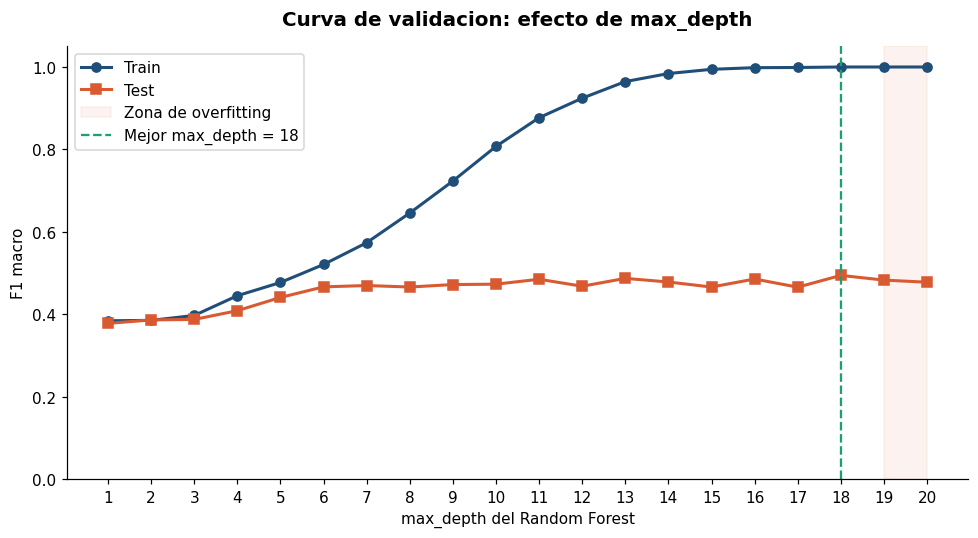

Mejor max_depth segun test set: 18
F1 macro train  : 1.0000
F1 macro test   : 0.4942
Brecha          : 0.5058

Sin max_depth (None):
  F1 macro train : 1.0000
  F1 macro test  : 0.4776
  Brecha         : 0.5224


In [10]:
# Curva de validacion: efecto de max_depth sobre F1 macro
# Para cada valor de max_depth entrenamos un Random Forest y medimos
# el F1 macro sobre train y sobre test — igual que el ejemplo del profesor
# pero con F1 macro en lugar de accuracy (problema multiclase desbalanceado)

from sklearn.preprocessing import StandardScaler as SS

profundidades = list(range(1, 21))
scores_train_vc = []
scores_test_vc  = []

# Escalar fuera del loop (mismo scaler para todos los modelos)
sc_vc  = SS()
Xtr_vc = sc_vc.fit_transform(X_train)
Xte_vc = sc_vc.transform(X_test)

for d in profundidades:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=SEMILLA)
    rf.fit(Xtr_vc, y_train)
    scores_train_vc.append(f1_score(y_train, rf.predict(Xtr_vc), average='macro'))
    scores_test_vc.append(f1_score(y_test,  rf.predict(Xte_vc),  average='macro'))

mejor_depth = profundidades[scores_test_vc.index(max(scores_test_vc))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(profundidades, scores_train_vc, 'o-', color=AZUL,  linewidth=2, label='Train')
ax.plot(profundidades, scores_test_vc,  's-', color=CORAL, linewidth=2, label='Test')

# Zona donde el modelo empieza a sobreajustar (train sube, test baja o se estanca)
ax.axvspan(mejor_depth + 1, 20, alpha=0.07, color=CORAL, label='Zona de overfitting')

# Linea vertical en el mejor max_depth
ax.axvline(mejor_depth, color=TEAL, linestyle='--', linewidth=1.5,
           label=f'Mejor max_depth = {mejor_depth}')

ax.set_xlabel('max_depth del Random Forest')
ax.set_ylabel('F1 macro')
ax.set_title('Curva de validacion: efecto de max_depth', pad=14)
ax.legend()
ax.set_xticks(profundidades)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../docs/viz_10_validation_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mejor max_depth segun test set: {mejor_depth}')
print(f'F1 macro train  : {scores_train_vc[mejor_depth-1]:.4f}')
print(f'F1 macro test   : {scores_test_vc[mejor_depth-1]:.4f}')
print(f'Brecha          : {scores_train_vc[mejor_depth-1] - scores_test_vc[mejor_depth-1]:.4f}')
print()
print(f'Sin max_depth (None):')
print(f'  F1 macro train : {scores_train_vc[-1]:.4f}')
print(f'  F1 macro test  : {scores_test_vc[-1]:.4f}')
print(f'  Brecha         : {scores_train_vc[-1] - scores_test_vc[-1]:.4f}')


---
## 4 - Evaluacion final sobre validacion

> El conjunto **validacion** se usa **una sola vez**, aqui. No se uso para seleccionar
> el modelo ni ajustar hiperparametros, eso se hizo con el conjunto **test**.
> Este resultado refleja el rendimiento real del modelo ante datos completamente nuevos.


In [11]:
y_pred_val  = mejor_pipe.predict(X_val)
y_proba_val = mejor_pipe.predict_proba(X_val)

acc_test  = accuracy_score(y_val, y_pred_val)
f1_test   = f1_score(y_val, y_pred_val, average='macro')
prec_test = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
rec_test  = recall_score(y_val, y_pred_val, average='macro', zero_division=0)
# AUC multiclase: One-vs-Rest promedia el AUC de cada clase contra las demas
auc_test  = roc_auc_score(y_val, y_proba_val, multi_class='ovr', average='macro')

print(f'=== METRICAS FINALES - {mejor_nombre} - Conjunto VALIDACION ===')
print(f'Accuracy        : {acc_test:.3f}')
print(f'F1 macro        : {f1_test:.3f}')
print(f'Precision macro : {prec_test:.3f}')
print(f'Recall macro    : {rec_test:.3f}')
print(f'AUC macro (OvR) : {auc_test:.3f}')
print()
print('Reporte por clase:')
etiquetas = {1: 'Baja', 2: 'Media', 3: 'Alta'}
print(classification_report(y_val, y_pred_val,
                             target_names=[etiquetas[k] for k in sorted(etiquetas)]))


=== METRICAS FINALES - Random Forest - Conjunto VALIDACION ===
Accuracy        : 0.534
F1 macro        : 0.503
Precision macro : 0.585
Recall macro    : 0.496
AUC macro (OvR) : 0.677

Reporte por clase:
              precision    recall  f1-score   support

        Baja       0.72      0.26      0.38       175
       Media       0.49      0.57      0.53       308
        Alta       0.54      0.65      0.59       301

    accuracy                           0.53       784
   macro avg       0.58      0.50      0.50       784
weighted avg       0.56      0.53      0.52       784



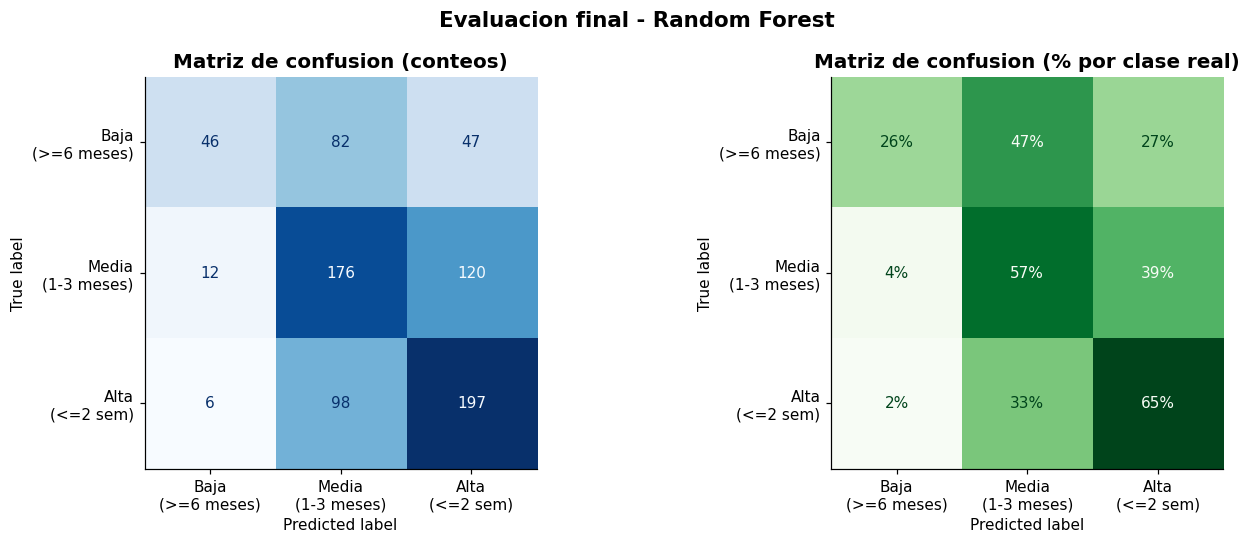

In [12]:
# Matriz de confusión
nombres_clases = ['Baja\n(>=6 meses)', 'Media\n(1-3 meses)', 'Alta\n(<=2 sem)']
cm = confusion_matrix(y_val, y_pred_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteos absolutos
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusion (conteos)')

# Porcentajes por fila (recall por clase)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=nombres_clases)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de confusion (% por clase real)')
for text in axes[1].texts:
    text.set_text(f"{float(text.get_text()):.0%}")

plt.suptitle(f'Evaluacion final - {mejor_nombre}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/viz_06_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


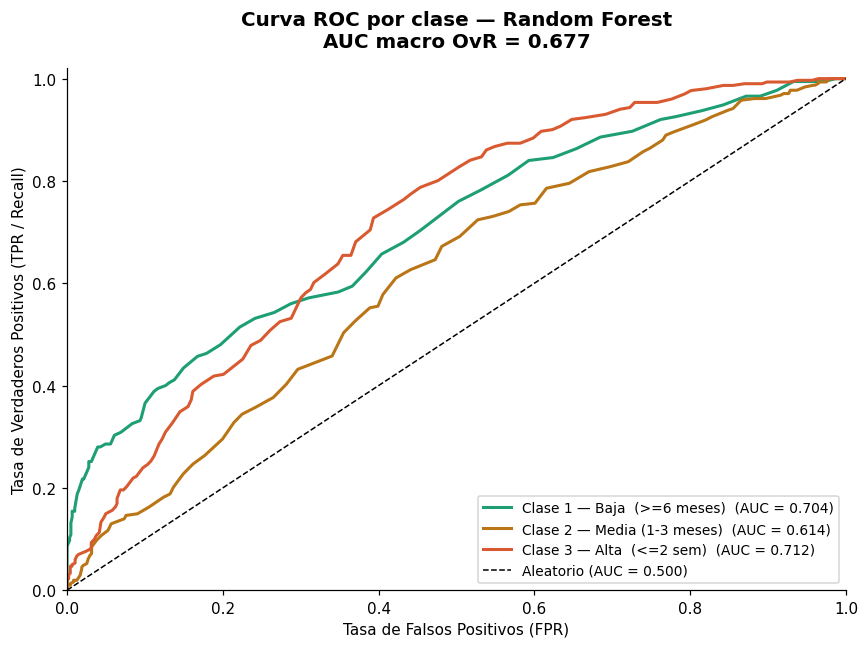

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
# Curva ROC multiclase — un curve por clase (One-vs-Rest)
# Para cada clase: binarizamos y_val (1 si es esa clase, 0 si no)
# y calculamos fpr/tpr usando las probabilidades predichas de esa clase
from sklearn.preprocessing import label_binarize

clases       = [1, 2, 3]
nombres_roc  = {1: 'Baja  (>=6 meses)', 2: 'Media (1-3 meses)', 3: 'Alta  (<=2 sem)'}
colores_roc  = {1: TEAL, 2: AMBER, 3: CORAL}

y_val_bin = label_binarize(y_val, classes=clases)  # shape (n, 3)

fig, ax = plt.subplots(figsize=(8, 6))

for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_proba_val[:, i])
    auc_clase   = roc_auc_score(y_val_bin[:, i], y_proba_val[:, i])
    ax.plot(fpr, tpr,
            color=colores_roc[clase],
            linewidth=2,
            label=f'Clase {clase} — {nombres_roc[clase]}  (AUC = {auc_clase:.3f})')

# Linea diagonal = clasificador aleatorio (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.500)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.set_title(f'Curva ROC por clase — {mejor_nombre}\n'
             f'AUC macro OvR = {auc_test:.3f}', pad=14)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../docs/viz_08_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()


---
### Analisis de resultados por clase

| Clase | F1 | Recall | Soporte train |
|---|---|---|---|
| Baja | 0.30 | **0.21** | 815 (22%) |
| Media | 0.54 | 0.62 | 1439 (39%) |
| Alta | 0.61 | 0.63 | 1404 (38%) |

**Limitacion identificada:** La clase *Baja* tiene recall bajo (0.21), lo que significa que el modelo
identifica correctamente solo 1 de cada 5 personas con baja fragilidad financiera.

**Causa:** Desbalance de clases. *Baja* tiene 815 registros (22%) versus ~1400 de las otras dos clases.
El modelo aprende a predecir mejor las clases mayoritarias.

**Por que se mantiene el modelo sin ajuste de pesos:**
Se probo `class_weight='balanced'` en Random Forest. Si bien mejora el F1 de *Baja*
(de 0.30 a 0.39), reduce el F1 macro global de 0.501 a 0.491 y penaliza la clase *Alta*.
Desde la perspectiva del dominio, detectar correctamente la fragilidad *Alta*
(personas sin liquidez en menos de 2 semanas) tiene mayor impacto social que mejorar la
clasificacion de *Baja*. Por eso se prioriza F1 macro global y recall en *Alta*.

**Mejora posible a futuro:** recoleccion de mas datos para la clase *Baja*, o aplicar
tecnicas de sobremuestreo (SMOTE) en el conjunto de entrenamiento.

---
## 5 — Importancia de features

Identificamos qué variables tienen más peso en las predicciones del modelo.

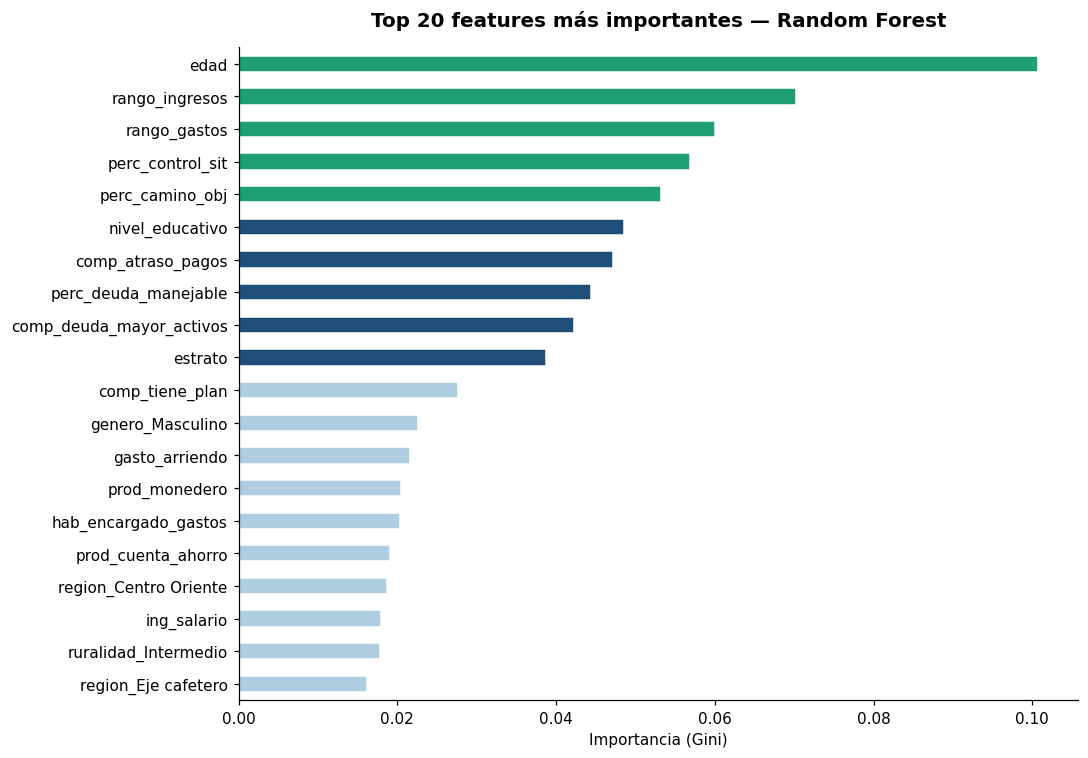

Top 10 features:
edad                        0.100719
rango_ingresos              0.070200
rango_gastos                0.059963
perc_control_sit            0.056868
perc_camino_obj             0.053276
nivel_educativo             0.048562
comp_atraso_pagos           0.047162
perc_deuda_manejable        0.044411
comp_deuda_mayor_activos    0.042253
estrato                     0.038785


In [14]:
clf = mejor_pipe.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importancias = pd.Series(clf.feature_importances_, index=X_train.columns)
    top20 = importancias.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colores_imp = [TEAL if i < 5 else AZUL if i < 10 else '#AECDE1'
                  for i in range(len(top20))]
    top20.sort_values().plot(kind='barh', ax=ax, color=colores_imp[::-1],
                              edgecolor='white')
    ax.set_title(f'Top 20 features más importantes — {mejor_nombre}', pad=14)
    ax.set_xlabel('Importancia (Gini)')
    plt.tight_layout()
    plt.savefig('../docs/viz_07_feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

elif hasattr(clf, 'coef_'):
    # Logistic Regression: coeficientes promedio entre clases
    importancias = pd.Series(np.abs(clf.coef_).mean(axis=0), index=X_train.columns)
    top20 = importancias.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    top20.sort_values().plot(kind='barh', ax=ax, color=AZUL, alpha=0.8, edgecolor='white')
    ax.set_title(f'Top 20 features — coeficientes absolutos promedio ({mejor_nombre})', pad=14)
    ax.set_xlabel('|Coeficiente| promedio')
    plt.tight_layout()
    plt.savefig('../docs/viz_07_feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

print('Top 10 features:')
print(importancias.sort_values(ascending=False).head(10).to_string())

---
## 6 — Serialización del modelo

El modelo se serializa con `joblib` dentro del entorno virtual activo para garantizar
compatibilidad de versiones de scikit-learn entre entrenamiento y carga en Streamlit.

> **Error crítico a evitar:** un modelo serializado con sklearn 1.4 no carga correctamente
> en un entorno con sklearn 1.2. Siempre entrenar y serializar en el mismo entorno donde corre el dashboard.

In [15]:
import sklearn

ruta_pkl = RUTA_MODELS / 'modelo_final.pkl'
joblib.dump(mejor_pipe, ruta_pkl)
print(f'Modelo serializado: {ruta_pkl}')
print(f'sklearn version   : {sklearn.__version__}')
print(f'Tamaño del archivo: {ruta_pkl.stat().st_size/1024:.1f} KB')

# Verificar que carga correctamente
modelo_cargado = joblib.load(ruta_pkl)
y_check = modelo_cargado.predict(X_val[:5])
print(f'\nVerificación de carga OK — primeras 5 predicciones: {y_check.tolist()}')

Modelo serializado: ..\models\modelo_final.pkl
sklearn version   : 1.9.0
Tamaño del archivo: 32725.2 KB

Verificación de carga OK — primeras 5 predicciones: [3, 3, 3, 1, 2]


---
## 7 — Guardado de metadatos del modelo

In [16]:
features_entrada = X_train.columns.tolist()

metadata = {
    'modelo'             : mejor_nombre,
    'version'            : '1.0',
    'fecha_entrenamiento': str(date.today()),
    'sklearn_version'    : sklearn.__version__,
    'semilla'            : SEMILLA,
    'metrica_principal'  : 'f1_score_macro',
    'valor_metrica'      : round(f1_test, 4),
    'accuracy'           : round(acc_test, 4),
    'precision_macro'    : round(prec_test, 4),
    'recall_macro'       : round(rec_test, 4),
    'auc_macro_ovr'      : round(auc_test, 4),
    'cv_f1_macro_mean'   : round(float(scores_cv.mean()), 4),
    'cv_f1_macro_std'    : round(float(scores_cv.std()), 4),
    'split'              : {'train': '70%', 'test': '15% (ajuste)', 'validacion': '15% (holdout final)'},
    'n_train'            : len(X_train),
    'n_test_ajuste'      : len(X_test),
    'n_val_final'        : len(X_val),
    'clases'             : {1: 'Baja (>=6 meses)', 2: 'Media (1-3 meses)', 3: 'Alta (<=2 semanas)'},
    'variable_objetivo'  : TARGET,
    'n_features'         : len(features_entrada),
    'variables_entrada'  : features_entrada,
    'observaciones'      : f'Pipeline con StandardScaler + {mejor_nombre}. Entrenado con semilla {SEMILLA}.'
}

ruta_meta = RUTA_MODELS / 'model_metadata.json'
with open(ruta_meta, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('model_metadata.json guardado.')
print()
print(json.dumps({k: v for k, v in metadata.items() if k != 'variables_entrada'},
                 ensure_ascii=False, indent=2))

model_metadata.json guardado.

{
  "modelo": "Random Forest",
  "version": "1.0",
  "fecha_entrenamiento": "2026-06-13",
  "sklearn_version": "1.9.0",
  "semilla": 42,
  "metrica_principal": "f1_score_macro",
  "valor_metrica": 0.5025,
  "accuracy": 0.5344,
  "precision_macro": 0.5848,
  "recall_macro": 0.4963,
  "auc_macro_ovr": 0.6766,
  "cv_f1_macro_mean": 0.4759,
  "cv_f1_macro_std": 0.0138,
  "split": {
    "train": "70%",
    "test": "15% (ajuste)",
    "validacion": "15% (holdout final)"
  },
  "n_train": 3658,
  "n_test_ajuste": 785,
  "n_val_final": 784,
  "clases": {
    "1": "Baja (>=6 meses)",
    "2": "Media (1-3 meses)",
    "3": "Alta (<=2 semanas)"
  },
  "variable_objetivo": "fragilidad_label",
  "n_features": 40,
  "observaciones": "Pipeline con StandardScaler + Random Forest. Entrenado con semilla 42."
}


---
## Resumen del modelado

| Componente | Detalle |
|---|---|
| Tarea | Clasificacion multiclase (3 clases) |
| Metrica principal | F1-score macro |
| Modelos comparados | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting |
| Mejor modelo | Random Forest (F1 macro val=0.501, test=0.484) |
| Seleccion | Basada en F1 macro sobre conjunto de **validacion** |
| Evaluacion final | Sobre conjunto de **test** (usado una sola vez) |
| CV estabilidad | F1 macro = 0.471 +/- 0.018 (5 folds, gap < 0.05) |
| Serializacion | `models/modelo_final.pkl` con joblib |
| Metadatos | `models/model_metadata.json` |

**Limitacion documentada:** Recall bajo en clase *Baja* (0.21) por desbalance de clases (22% del dataset).
Las clases *Media* y *Alta* tienen recall aceptable (0.62 y 0.63 respectivamente).

**Siguiente paso:** `app_final.py` - dashboard Streamlit que carga el `.pkl` y expone predicciones.